# MetaSort Blood Demo

Run MetaSort on the first 100 Blood mixtures, then visualize cumulative accuracy distributions for the first 20, 40, 60, 80, and 100 mixtures.

Accuracy is defined as `1 - L1 / 2`.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
candidates = [CWD, CWD.parent]
REPO_ROOT = next((path for path in candidates if (path / 'metasort').exists() and (path / 'data').exists()), None)
if REPO_ROOT is None:
    raise RuntimeError('Run this notebook from the MetaSort repository root or notebooks directory.')

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from metasort.algorithm import load_bulk_signature_inputs
from metasort import MetaSortConfig, MetaSortSolver

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
DATA_ROOT = REPO_ROOT / 'data'
tissue_names = ['Blood']
n_mixtures = 100
cumulative_windows = [20, 40, 60, 80, 100]
RECOMPUTE = False

cfg = MetaSortConfig(
    lambda_hessian=1.0,
    lambda_avg_gradient=1.0,
    lambda_residual=1.5,
    lambda_gene_importance=0.0,
    lambda3=0.01,
    lambda4=0.001,
    convergence_tol=0.005,
    print_info=False,
)
solver = MetaSortSolver(cfg)


In [3]:
def run_one_mixture(tissue_name: str, mixture_name: str) -> dict:
    tissue_root = DATA_ROOT / tissue_name
    signature, bulk, _, cell_types = load_bulk_signature_inputs(tissue_root, mixture_name=mixture_name)
    ratio_df = pd.read_csv(tissue_root / 'bulkRatio.txt', sep='	', index_col=0)
    truth = ratio_df.loc[cell_types, mixture_name].to_numpy(dtype=float)
    truth = truth / np.sum(truth)

    result = solver.solve(signature, bulk, cell_types=cell_types)
    pred = np.asarray(result.proportions, dtype=float)
    l1_error = float(np.sum(np.abs(pred - truth)))
    accuracy = float(1.0 - l1_error / 2.0)

    row = {
        'Tissue': tissue_name,
        'Mixture': mixture_name,
        'L1_Error': l1_error,
        'Accuracy': accuracy,
        'Iterations': result.iterations,
    }
    for cell_type, value in zip(cell_types, pred):
        row[f'Pred_{cell_type}'] = float(value)
    for cell_type, value in zip(cell_types, truth):
        row[f'Truth_{cell_type}'] = float(value)
    return row


def run_tissue(tissue_name: str, n: int) -> list[dict]:
    tissue_root = DATA_ROOT / tissue_name
    ratio_df = pd.read_csv(tissue_root / 'bulkRatio.txt', sep='	', index_col=0)
    mixtures = list(ratio_df.columns[:n])
    return [run_one_mixture(tissue_name, mixture) for mixture in mixtures]


In [4]:
result_path = REPO_ROOT / 'metasort_blood_first100_deconvolution.csv'

if result_path.exists() and not RECOMPUTE:
    summary_df = pd.read_csv(result_path)
else:
    rows = []
    for tissue in tissue_names:
        rows.extend(run_tissue(tissue, n=n_mixtures))
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(result_path, index=False)

summary_df.head()


,Tissue,Mixture,L1_Error,Accuracy,Iterations,Pred_erythrocyte,Pred_classical_monocyte,Pred_neutrophil,Pred_memory_B_cell,Pred_plasma_cell,Pred_platelet,Truth_erythrocyte,Truth_classical_monocyte,Truth_neutrophil,Truth_memory_B_cell,Truth_plasma_cell,Truth_platelet
0,Blood,Mixture1,0.110333,0.944834,14,0.252540,0.539336,0.000907,0.087835,0.099429,0.019951,0.245253,0.492365,0.000000,0.089474,0.124192,0.048716
1,Blood,Mixture2,0.169119,0.915440,23,0.000000,0.241843,0.573484,0.080871,0.027823,0.075979,0.000000,0.259984,0.494718,0.116338,0.058774,0.070186
2,Blood,Mixture3,0.297001,0.851499,16,0.355340,0.077168,0.360080,0.125368,0.052227,0.029816,0.312816,0.000000,0.449739,0.096560,0.087968,0.052916
3,Blood,Mixture4,0.177055,0.911473,23,0.299224,0.174670,0.387987,0.082975,0.051631,0.003512,0.266262,0.136687,0.440875,0.065393,0.070122,0.020660
4,Blood,Mixture5,0.138149,0.930925,17,0.276759,0.415747,0.158338,0.086439,0.042244,0.020472,0.271515,0.363712,0.203610,0.074643,0.047378,0.039142


/tmp/ipykernel_940976/621027789.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


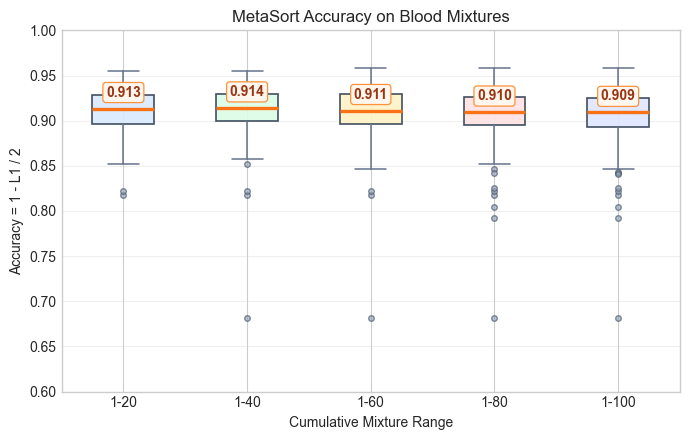

In [5]:
plot_df = summary_df.copy()
plot_df['MixtureIndex'] = plot_df['Mixture'].str.extract(r'(\d+)').astype(int)
plot_df = plot_df.sort_values('MixtureIndex')

box_data = [plot_df.loc[plot_df['MixtureIndex'] <= n, 'Accuracy'].to_numpy() for n in cumulative_windows]
labels = [f'1-{n}' for n in cumulative_windows]
median_values = [float(np.median(values)) for values in box_data]

fig, ax = plt.subplots(figsize=(7, 4.5))
box = ax.boxplot(
    box_data,
    labels=labels,
    patch_artist=True,
    medianprops={'color': '#f97316', 'linewidth': 2.4},
    boxprops={'linewidth': 1.2, 'color': '#334155'},
    whiskerprops={'linewidth': 1.1, 'color': '#64748b'},
    capprops={'linewidth': 1.1, 'color': '#64748b'},
    flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': '#94a3b8', 'markeredgecolor': '#475569', 'alpha': 0.65},
)

box_colors = ['#dbeafe', '#dcfce7', '#fef3c7', '#fee2e2', '#e0e7ff']
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.92)

for x, median_value in enumerate(median_values, start=1):
    ax.text(
        x,
        median_value + 0.010,
        f'{median_value:.3f}',
        ha='center',
        va='bottom',
        color='#9a3412',
        fontsize=10,
        fontweight='bold',
        bbox={'boxstyle': 'round,pad=0.22', 'facecolor': '#fff7ed', 'edgecolor': '#fb923c', 'linewidth': 0.9},
    )

ax.set_title('MetaSort Accuracy on Blood Mixtures')
ax.set_xlabel('Cumulative Mixture Range')
ax.set_ylabel('Accuracy = 1 - L1 / 2')
ax.set_ylim(0.6, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


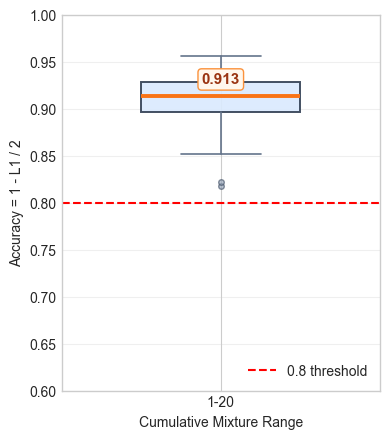

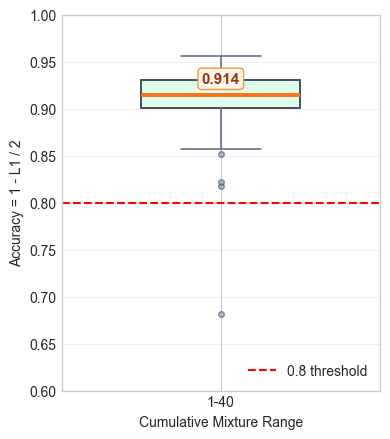

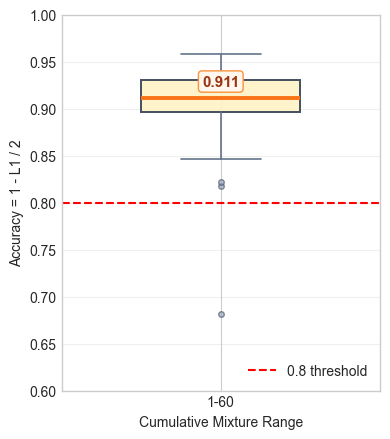

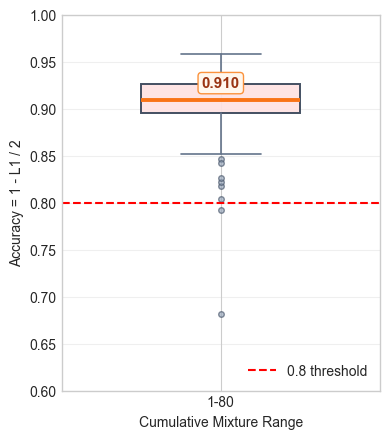

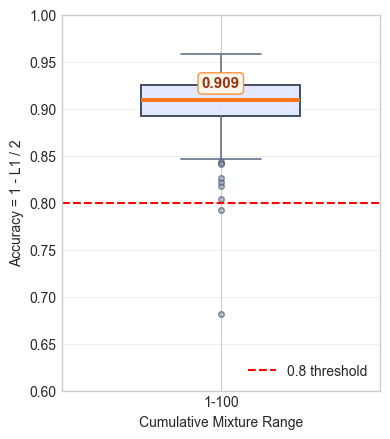

In [16]:
plot_df = summary_df.copy()
plot_df["MixtureIndex"] = plot_df["Mixture"].str.extract(r"(\d+)").astype(int)
plot_df = plot_df.sort_values("MixtureIndex")

box_data = [
    plot_df.loc[plot_df["MixtureIndex"] <= n, "Accuracy"].to_numpy()
    for n in cumulative_windows
]
labels = [f"1-{n}" for n in cumulative_windows]
median_values = [float(np.median(values)) for values in box_data]
box_colors = ["#dbeafe", "#dcfce7", "#fef3c7", "#fee2e2", "#e0e7ff"]

for values, label, median_value, color in zip(box_data, labels, median_values, box_colors):
    fig, ax = plt.subplots(figsize=(4, 4.5))

    box = ax.boxplot(
        [values],
        tick_labels=[label],
        widths=0.55,
        patch_artist=True,
        medianprops={"color": "#f97316", "linewidth": 2.8},
        boxprops={"linewidth": 1.4, "color": "#334155"},
        whiskerprops={"linewidth": 1.2, "color": "#64748b"},
        capprops={"linewidth": 1.2, "color": "#64748b"},
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "#94a3b8",
            "markeredgecolor": "#475569",
            "alpha": 0.65,
        },
    )

    box["boxes"][0].set_facecolor(color)
    box["boxes"][0].set_alpha(0.92)

    ax.text(
        1,
        median_value + 0.010,
        f"{median_value:.3f}",
        ha="center",
        va="bottom",
        color="#9a3412",
        fontsize=11,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.24",
            "facecolor": "#fff7ed",
            "edgecolor": "#fb923c",
            "linewidth": 1.0,
        },
    )

    ax.set_xlabel("Cumulative Mixture Range")
    ax.set_ylabel("Accuracy = 1 - L1 / 2")
    ax.set_ylim(0.6, 1)
    ax.set_xlim(0.45, 1.55)
    ax.axhline(0.8, color="red", linestyle="--", linewidth=1.5, label="0.8 threshold")
    ax.legend(frameon=False, loc="lower right")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [7]:
pd.DataFrame([
    {
        'MixtureRange': f'1-{n}',
        'N': int((plot_df['MixtureIndex'] <= n).sum()),
        'MeanAccuracy': float(plot_df.loc[plot_df['MixtureIndex'] <= n, 'Accuracy'].mean()),
        'MedianAccuracy': float(plot_df.loc[plot_df['MixtureIndex'] <= n, 'Accuracy'].median()),
        'MeanL1Error': float(plot_df.loc[plot_df['MixtureIndex'] <= n, 'L1_Error'].mean()),
    }
    for n in cumulative_windows
])


,MixtureRange,N,MeanAccuracy,MedianAccuracy,MeanL1Error
0,1-20,20,0.905282,0.913456,0.189437
1,1-40,40,0.903802,0.914162,0.192395
2,1-60,60,0.904831,0.911261,0.190338
3,1-80,80,0.901773,0.909580,0.196455
4,1-100,100,0.900408,0.909193,0.199183


In [8]:
summary_df.to_csv(result_path, index=False)
result_path


PosixPath('/home/yunhao/WeightOptimizationDebug/metasort_jk/metasort_blood_first100_deconvolution.csv')